# Retail Sales and Profitability Analysis
Welcome to my Retail Sales and Profitability Analysis project! In this notebook, I am going to explore a business dataset to clean the information, find cool trends, and discover which products are making the most money.

## Project Goals
1. **Load and Clean the Dataset**: Handle missing values and format data types.
2. **Exploratory Data Analysis (EDA)**: Understand the dataset structure.
3. **Sales Trends Over Time**: Visualize how revenue changes over days/months.
4. **Top Selling Products**: Identify which products generate the most volume and revenue.
5. **Revenue by Region**: Determine which geographic regions are performing best.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load and Clean the Dataset

In [2]:
# Load data
df = pd.read_csv('sales_data.csv', encoding='unicode_escape')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# Check for missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill missing quantities with median
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Recalculate missing revenue based on price and quantity
df['Sales'] = df['Sales'].fillna(0)

print("\nMissing values after cleaning:\n", df.isnull().sum())

Missing values before cleaning:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Missing values after cleaning:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


## 2. Exploratory Data Analysis

In [4]:
# Summary statistics
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [5]:
# Find total revenue and items sold
total_revenue = df['Sales'].sum()
total_items = df['Quantity'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Items Sold: {total_items:,.0f}")

Total Revenue: $2,297,200.86
Total Items Sold: 37,873


## 3. Analyze Sales Trends Over Time

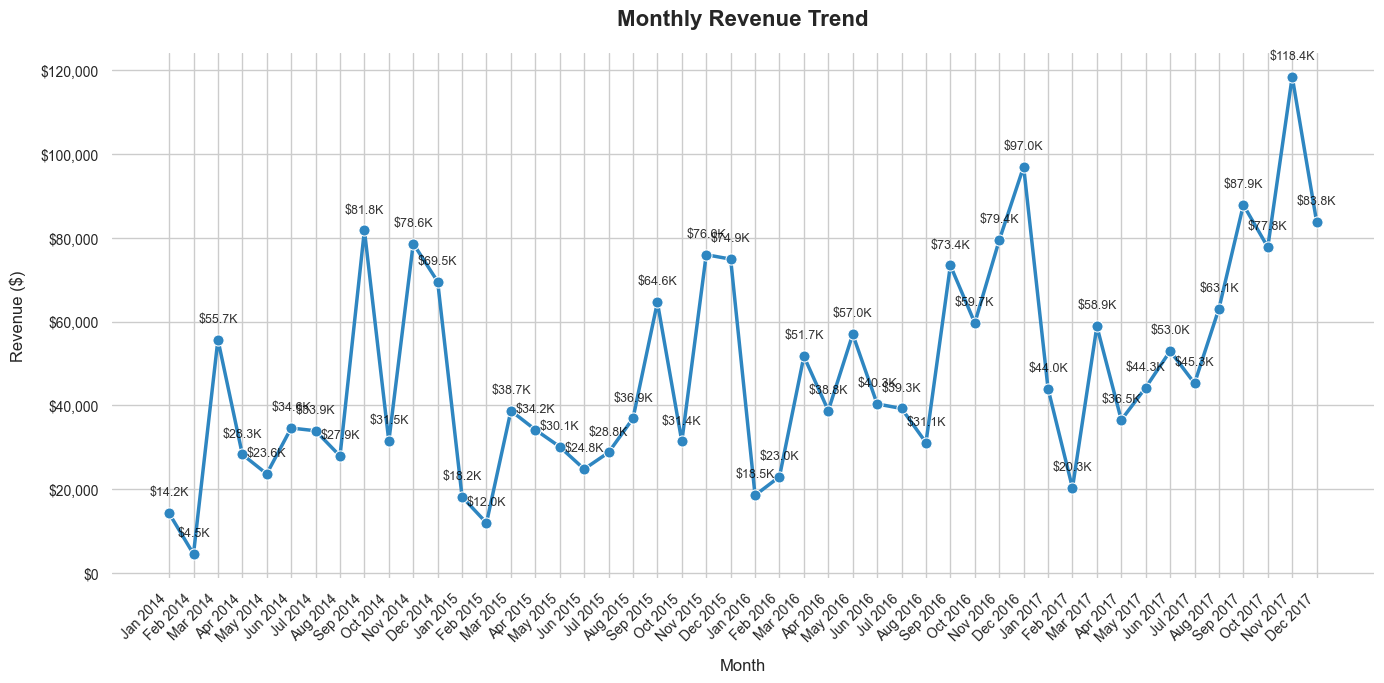

In [6]:
import matplotlib.ticker as ticker

# Set a professional seaborn theme
sns.set_theme(style="whitegrid")

# Group by month to see trends
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].dt.strftime('%b %Y')

plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o', color='#2E86C1', linewidth=2.5, markersize=8)

plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Month', fontsize=12, labelpad=10)
plt.ylabel('Revenue ($)', fontsize=12, labelpad=10)

# Format y-axis with dollar sign and commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '${:,.0f}'.format(x)))

# Add data labels for points (in thousands to avoid clutter)
y_offset = monthly_sales['Sales'].max() * 0.03
for i, row in monthly_sales.iterrows():
    ax.text(i, row.Sales + y_offset, f'${row.Sales/1000:,.1f}K', 
            ha='center', va='bottom', fontsize=9, color='black', alpha=0.8)

# Enhance spines
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300, transparent=False, facecolor='white')
plt.show()


## 4. Identify Top Selling Products

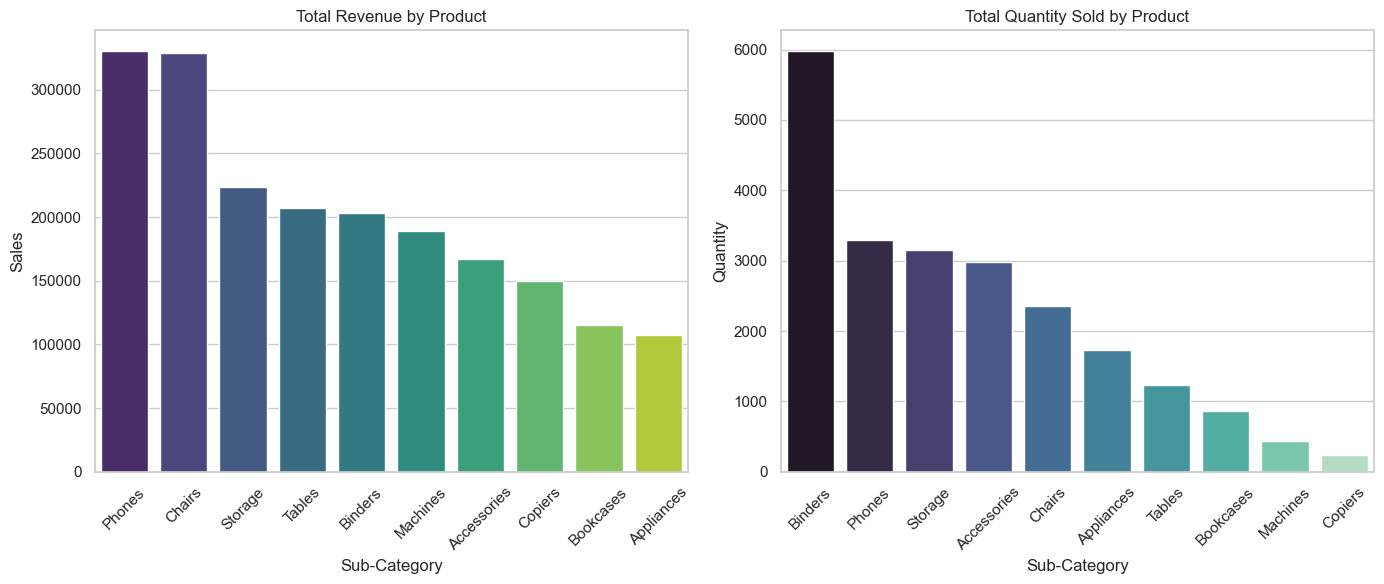

In [7]:
product_sales = df.groupby('Sub-Category').agg({'Quantity': 'sum', 'Sales': 'sum'}).reset_index()
product_sales = product_sales.sort_values(by='Sales', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart for Revenue
sns.barplot(ax=axes[0], data=product_sales, x='Sub-Category', y='Sales', hue='Sub-Category',  palette='viridis', legend=False)
axes[0].set_title('Total Revenue by Product')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart for Quantity
product_sales_qty = product_sales.sort_values(by='Quantity', ascending=False)
sns.barplot(ax=axes[1], data=product_sales_qty, x='Sub-Category', y='Quantity', hue='Sub-Category', palette='mako', legend=False)
axes[1].set_title('Total Quantity Sold by Product')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('product_performance.png')
plt.show()

## 5. Analyze Revenue by Region

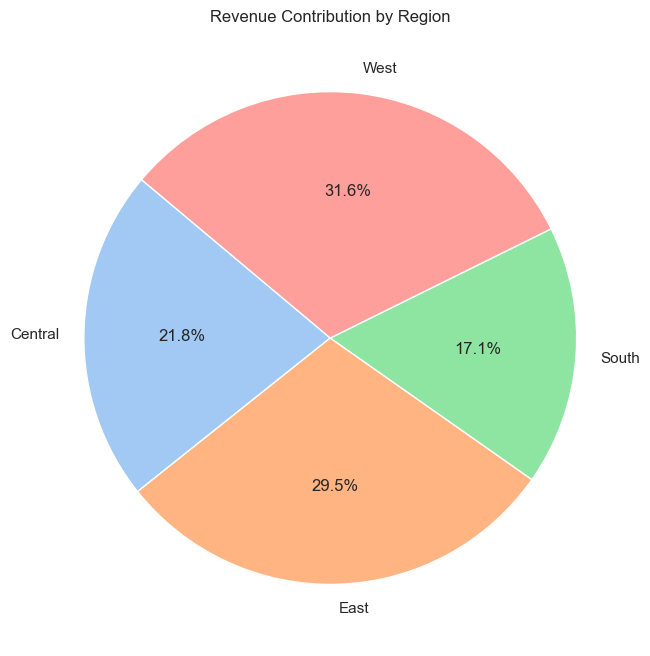

In [8]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(region_sales['Sales'], labels=region_sales['Region'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Contribution by Region')
plt.savefig('regional_revenue.png')
plt.show()

## Summarizing the Findings
- We observed the monthly revenue trends which showed fluctuations throughout the year.
- We identified the top 10 sub-categories by sales and quantity, highlighting our most successful product lines.
- Regional split shows how balanced or skewed our sales force is performing across different territories.

This concludes the Sales Analysis Notebook!